<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

### Requirements:
- Identify the single feature of the data that is the best predictor of whether a customer will put in a claim (the "outcome" column), excluding the "id" column.

- Store as a DataFrame called best_feature_df, containing columns named "best_feature" and "best_accuracy" with the name of the feature with the highest accuracy, and the respective accuracy score.

In [ ]:
# Import required modules
import pandas as pd
import numpy as np
from statsmodels.formula.api import logit
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
car_insurance = pd.read_csv("car_insurance.csv")
car_insurance.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [ ]:
# Check for columns with null values
car_insurance.isnull().sum()

id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

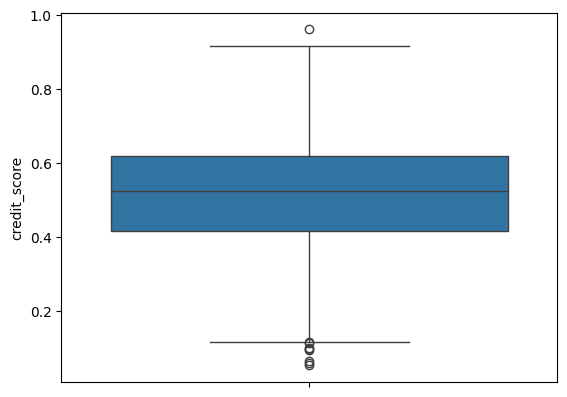

In [ ]:
# Check the distribution of credit_score values
sns.boxplot(y="credit_score",data=car_insurance)
plt.show()

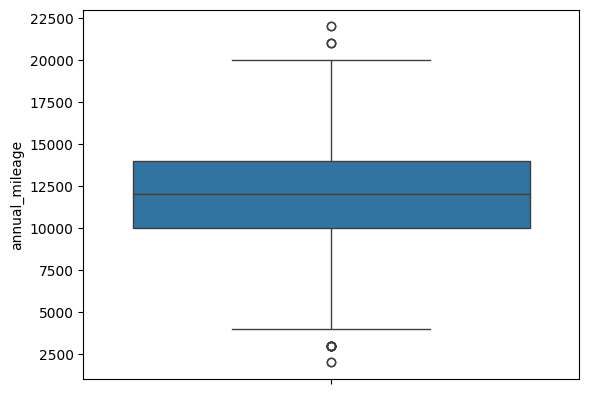

In [ ]:
# Check the distribution of annual_mileage values
sns.boxplot(y="annual_mileage",data=car_insurance)
plt.show()

### Since 18% is a significant amount of rows, we cannot simply drop rows with null values

In [ ]:
# Compute the percentage of missing rows
nulls = car_insurance.isnull().any(axis=1).sum()
print("No. of null rows: " + str(nulls))
print("Total No. of rows in dataset: " + str(len(car_insurance)))
percentage = nulls/len(car_insurance)*100
print("Percentage of null rows: " + str(round(percentage,2))+"%")

No. of null rows: 1851
Total No. of rows in dataset: 10000
Percentage of null rows: 18.51%


### Since the boxplot indicates the presence of outliers, we will impute null values with the median value of the column

In [ ]:
# Fill null values with the median value of its respective column
car_insurance["annual_mileage"] = car_insurance["annual_mileage"].fillna(car_insurance["annual_mileage"].median())
car_insurance["credit_score"] = car_insurance["credit_score"].fillna(car_insurance["credit_score"].median())

car_insurance.isnull().sum()

id                     0
age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
postal_code            0
annual_mileage         0
vehicle_type           0
speeding_violations    0
duis                   0
past_accidents         0
outcome                0
dtype: int64

In [ ]:

def create_model(predictor):
    """Returns a model that predicts whether the client made an insurance claim using the predictor variable
    
    Args:
        predictor(str): The column name of the predictor variable to be used
        
    Returns:
        model: the resulting model after applying the logit function to the response and predictor variables
    """
    
    model = logit(f"outcome ~ {predictor}",car_insurance).fit(disp=0)
    return model

def compute_accuracy(model):
    """Returns the accuracy of a model by utilizing the confusion matrix of the model
    
    Args:
        model: The model that you want to compute the accuracy"
        
    Returns:
        int: the value for accuracy of the model
    
    """
    conf_matrix = model.pred_table()
    
    TN = conf_matrix[0,0] 
    TP = conf_matrix[1,1] 
    FN = conf_matrix[1,0] 
    FP = conf_matrix[0,1]
    accuracy = (TN + TP) / (TN + TP + FN + FP) 
    
    return accuracy

In [ ]:
# Specify the columns not to be used as a feature
columns_to_exclude=["id","outcome"]

# Create a list of the features via list comprehension
features_to_test = [col for col in car_insurance.columns if col not in columns_to_exclude]

In [ ]:
# Initialize the variables that will store the feature with the best accuracy
best_feature = ""
best_accuracy = 0

# Create a model using each feature and compute for its accuracy
for feature in features_to_test:
    model = create_model(feature)
    accuracy = compute_accuracy(model)
    print(f"Model accuracy using {feature}: " + str(accuracy))
    if(accuracy > best_accuracy):
        best_accuracy = accuracy
        best_feature = feature

# Display the best performing feature and its accuracy
print("\nBest Feature: " + best_feature)
print("Best Accuracy: " +str(best_accuracy))

Model accuracy using age: 0.7747
Model accuracy using gender: 0.6867
Model accuracy using driving_experience: 0.7771
Model accuracy using education: 0.6867
Model accuracy using income: 0.7425
Model accuracy using credit_score: 0.7053
Model accuracy using vehicle_ownership: 0.7351
Model accuracy using vehicle_year: 0.6867
Model accuracy using married: 0.6867
Model accuracy using children: 0.6867
Model accuracy using postal_code: 0.6867
Model accuracy using annual_mileage: 0.6904
Model accuracy using vehicle_type: 0.6867
Model accuracy using speeding_violations: 0.6867
Model accuracy using duis: 0.6867
Model accuracy using past_accidents: 0.6867

Best Feature: driving_experience
Best Accuracy: 0.7771


In [ ]:
# Create a dictionary that stores the name of the best feature and its accuracy
best_feature_dict = [{"best_feature":best_feature, "best_accuracy":best_accuracy}]

# Create a dataframe for the data
best_feature_df = pd.DataFrame(best_feature_dict)

# Display the data
best_feature_df

,best_feature,best_accuracy
0,driving_experience,0.7771
